# Severity model

This notebook predicts how much a claim costs, given that one has happened. It covers:

1. choosing a cap for large individual claims, and what happens to the cost above the cap;
2. a **Gamma GLM** on average claim cost per policy, weighted by the number of claims;
3. a **LightGBM** model with a Gamma objective, for comparison.

As in the frequency notebook, all choices are made on the training data (5-fold cross-validation) and the test set is scored once at the end. Severity metrics are weighted by number of claims.

In [1]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.model_selection import KFold

from pricing.data import (
    LARGE_LOSS_CAP, PROJECT_ROOT, RANDOM_SEED, build_policy_table, load_raw, severity_rows, split_train_test,
)
from pricing.evaluation import balance, calibration_table, gamma_deviance, gini, one_way_table
from pricing.features import (
    BANDS, GLM_FACTORS, add_glm_bands, band_labels, base_levels, gbm_matrix, glm_design_matrix, glm_levels,
)
from pricing.gbm import SeverityGBM, cv_gamma_gbm
from pricing.glm import drop_factor_tests, fit_gamma_glm, predict, relativities
from pricing.plots import plot_calibration, plot_relativities, save, set_style

set_style()
pl.Config.set_tbl_rows(40)
pl.Config.set_float_precision(4)
PROCESSED = PROJECT_ROOT / "data" / "processed"

In [2]:
freq_raw, sev_raw = load_raw()
train, test = split_train_test(build_policy_table(freq_raw, sev_raw))

# Individual training claims, before any cap.
train_claims = sev_raw.join(train.select("IDpol"), on="IDpol")["ClaimAmount"].to_numpy()
print(f"{len(train_claims):,} training claims, total EUR {train_claims.sum():,.0f}")

21,044 training claims, total EUR 48,041,113


## 1. Choosing the large-loss cap

The EDA showed that a handful of claims carry a large share of the cost: the single largest is EUR 4.1m, 6.7% of all claim cost. A severity model fitted to uncapped amounts is dominated by those few claims, and its average level depends on which of them happen to fall in the training data.

Capping each claim at a threshold trades two things off:

- a **lower cap** gives a more stable average cost, but moves more cost into a flat loading that is not priced by risk factor;
- a **higher cap** keeps more cost risk-rated, but leaves more noise in the model.

The table compares candidate caps on the training claims. The last column is the bootstrap uncertainty in the average claim cost: resample the training claims with replacement many times and measure how much the average moves (standard deviation divided by mean).

In [3]:
rng = np.random.default_rng(RANDOM_SEED)
boot_idx = rng.integers(0, len(train_claims), (300, len(train_claims)))
rows = []
for cap in [None, 10_000, 20_000, 50_000, 100_000, 200_000]:
    capped = train_claims if cap is None else np.minimum(train_claims, cap)
    boot_means = capped[boot_idx].mean(axis=1)
    rows.append({
        "cap (EUR)": "none" if cap is None else f"{cap:,}",
        "claims above cap": int((train_claims > cap).sum()) if cap else 0,
        "share of claims above": float((train_claims > cap).mean()) if cap else 0.0,
        "share of cost removed": float(1 - capped.sum() / train_claims.sum()),
        "average capped claim": float(capped.mean()),
        "uncertainty in average": float(boot_means.std() / boot_means.mean()),
    })
pl.DataFrame(rows)

cap (EUR),claims above cap,share of claims above,share of cost removed,average capped claim,uncertainty in average
str,i64,f64,f64,f64,f64
"""none""",0,0.0000,0.0000,2282.8888,0.1020
"""10,000""",382,0.0182,0.3512,1481.1991,0.0082
"""20,000""",166,0.0079,0.2996,1598.8973,0.0108
"""50,000""",66,0.0031,0.2363,1743.4092,0.0157
"""100,000""",32,0.0015,0.1903,1848.5644,0.0213
"""200,000""",15,0.0007,0.1430,1956.4671,0.0282


The cap is set at **EUR 50,000** (`LARGE_LOSS_CAP` in `pricing/data.py`):

- It affects 66 training claims (0.3%). No model can learn a pattern from that few, so there is little to lose by taking them out of the severity model.
- It cuts the uncertainty in the average claim cost from about 10% to about 1.4%.
- It keeps more cost risk-rated than a EUR 20,000 cap, which would only reduce the uncertainty a little further (to 1.0%) while moving another 6% of cost into the flat loading.

The choice is a judgement, and EUR 100,000 would also be defensible. A real pricing team would also look at large-loss history over several years, which this dataset does not have.

## 2. What happens to the cost above the cap

The cost above the cap has not gone away: it still has to be paid for. In practice it is spread across all policies as a **large-loss loading**. The simplest version, used here, is a percentage added to every policy's capped pure premium:

$$\text{loading} = \frac{\text{total cost above the cap}}{\text{total capped cost}}$$

In [4]:
train_capped = build_policy_table(freq_raw, sev_raw, large_loss_cap=LARGE_LOSS_CAP)
train_capped, test_capped = split_train_test(train_capped)
assert (train_capped["IDpol"] == train["IDpol"]).all()

excess = train_capped["ClaimAmountExcess"].sum()
capped_cost = train_capped["ClaimAmount"].sum()
largest = train_claims.max()
loading = excess / capped_cost
loading_without_largest = (excess - (largest - LARGE_LOSS_CAP)) / capped_cost
pl.DataFrame({
    "measure": ["capped claim cost (EUR)", "cost above cap (EUR)", "large-loss loading",
                "largest single training claim (EUR)", "loading without that one claim"],
    "value": [capped_cost, excess, loading, largest, loading_without_largest],
})

measure,value
str,f64
"""capped claim cost (EUR)""",36688304.0600
"""cost above cap (EUR)""",11352808.6000
"""large-loss loading""",0.3094
"""largest single training claim …",4075400.5600
"""loading without that one claim""",0.1997


The loading on this training data is large, about 31% on top of the capped cost, and it depends heavily on single claims: removing the one EUR 4.1m claim alone brings it down to about 20%. This is the same instability the cap removes from the severity model, now moved into one number. In practice the loading would be estimated from many years of large-loss experience, or from a separate model of large-claim frequency and size (often a Pareto distribution above the threshold), not from one sample.

The loading is not applied in the model comparisons that follow, because it multiplies every policy by the same factor and so changes neither ranking nor relative accuracy. It is carried through to the pure premium notebook so that total premium covers total cost.

## 3. The severity data

Severity is modelled at policy level: for each policy with at least one claim, the **average capped cost per claim**. A policy with three claims contributes one row, with an average over three claims and a weight of 3.

In [5]:
sev_train = severity_rows(train_capped)
sev_test = severity_rows(test_capped)
y_train, w_train = sev_train["AvgClaim"].to_numpy(), sev_train["SevNb"].to_numpy().astype(float)
y_test, w_test = sev_test["AvgClaim"].to_numpy(), sev_test["SevNb"].to_numpy().astype(float)
train_mean = np.average(y_train, weights=w_train)
print(f"Train: {sev_train.height:,} policies with claims, {w_train.sum():,.0f} claims, average EUR {train_mean:,.0f}")
print(f"Test:  {sev_test.height:,} policies with claims, {w_test.sum():,.0f} claims")

Train: 19,843 policies with claims, 21,044 claims, average EUR 1,743
Test:  5,101 policies with claims, 5,400 claims


### Why Gamma, and why weight by claim count

Claim costs are positive and right-skewed, and their spread grows with their size: expensive claim types vary by thousands, cheap ones by tens. The **Gamma** distribution has exactly this shape: its standard deviation is proportional to its mean. The Gamma deviance therefore judges errors in proportion to the size of the claim, so a EUR 500 miss on a EUR 1,000 claim counts as much as a EUR 5,000 miss on a EUR 10,000 claim.

An average of three claims is less variable than a single claim (its variance is a third as large), so it carries three times the information. Weighting by claim count gives each claim, not each policy, an equal say. The weights are passed to statsmodels as variance weights for this reason.

## 4. Gamma GLM: which factors to use

Frequency used all eight factors. Severity has far less data behind it (about 20,000 claims against 540,000 policies) and, as the EDA suggested, a weaker signal. The GLM is first fitted with every factor, using the same bands and base levels as the frequency GLM, so that frequency and severity relativities can later be combined.

In [6]:
sev_train_b = add_glm_bands(sev_train)
freq_train_b = add_glm_bands(train_capped)
levels, base = glm_levels(freq_train_b), base_levels(freq_train_b)
X_full = glm_design_matrix(sev_train_b, levels, base)
glm_full = fit_gamma_glm(X_full, y_train, w_train)
print(f"Dispersion (estimated Gamma shape parameter inverse): {glm_full.scale:.2f}")

tests = drop_factor_tests(lambda X: fit_gamma_glm(X, y_train, w_train), X_full, GLM_FACTORS, glm_full)
tests

Dispersion (estimated Gamma shape parameter inverse): 4.31


factor,columns,deviance_increase,F,p_value
str,i64,f64,f64,f64
"""BonusMalus""",7,107.5292,3.5655,0.0008
"""DrivAge""",10,129.5210,3.0063,0.0008
"""Density""",7,84.2290,2.7929,0.0066
"""Region""",21,144.4525,1.5966,0.0408
"""VehAge""",4,42.0178,2.4382,0.0448
"""VehPower""",8,62.5672,1.8153,0.0692
"""VehBrand""",10,26.7842,0.6217,0.7967
"""VehGas""",1,0.0868,0.0202,0.8871


Each row refits the GLM without one factor and tests whether the fit gets significantly worse (an F-test, since the Gamma dispersion is estimated). BonusMalus, DrivAge and Density are clearly significant. Region and VehAge are borderline, and VehPower, VehBrand and VehGas show no effect on claim cost once the others are included.

Significance on the training data is one guide. The deciding test is whether a factor improves predictions on data the model has not seen, so candidate factor sets are compared with 5-fold cross-validation:

In [7]:
candidates = {
    "no factors": [],
    "BonusMalus, DrivAge, Density": ["BonusMalus", "DrivAge", "Density"],
    "+ VehAge": ["BonusMalus", "DrivAge", "Density", "VehAge"],
    "+ VehAge, Region": ["BonusMalus", "DrivAge", "Density", "VehAge", "Region"],
    "all factors": GLM_FACTORS,
}
folds = list(KFold(5, shuffle=True, random_state=RANDOM_SEED).split(y_train))


def cv_glm(factors):
    X = glm_design_matrix(sev_train_b, {f: levels[f] for f in factors}, base)
    oof = np.zeros_like(y_train)
    for fit_idx, val_idx in folds:
        res = fit_gamma_glm(X.iloc[fit_idx], y_train[fit_idx], w_train[fit_idx])
        oof[val_idx] = predict(res, X.iloc[val_idx])
    return X.shape[1], oof


cv_rows, oof = [], {}
for name, factors in candidates.items():
    n_params, oof[name] = cv_glm(factors)
    cv_rows.append({
        "factors": name,
        "parameters": n_params,
        "cv_gamma_deviance": gamma_deviance(y_train, oof[name], w_train),
        "cv_gini": gini(y_train * w_train, oof[name], w_train),
    })
pl.DataFrame(cv_rows)

factors,parameters,cv_gamma_deviance,cv_gini
str,i64,f64,f64
"""no factors""",1,1.1880,-0.0091
"""BonusMalus, DrivAge, Density""",25,1.1818,0.0474
"""+ VehAge""",29,1.1818,0.0481
"""+ VehAge, Region""",50,1.1833,0.0545
"""all factors""",69,1.1895,0.0499


The GLM with every factor does **worse** on unseen data than a model with no factors at all. With 69 parameters, a weak signal and noisy targets, it fits more noise than pattern. Three factors give the best cross-validated deviance, and adding VehAge makes no measurable difference, so the simpler model is kept:

**Severity GLM factors: BonusMalus, DrivAge, Density.**

The improvement over no factors is small (under 1% of deviance). Claim cost is much harder to predict from these rating factors than claim frequency, partly because around 44% of claims are settled at near-fixed amounts, as the EDA showed.

In [8]:
SEV_FACTORS = ["BonusMalus", "DrivAge", "Density"]
sev_levels = {f: levels[f] for f in SEV_FACTORS}
X_train_glm = glm_design_matrix(sev_train_b, sev_levels, base)
glm = fit_gamma_glm(X_train_glm, y_train, w_train)
rel = relativities(glm, sev_levels, base)
print(f"Base severity (all factors at base level): EUR {np.exp(glm.params['const']):,.0f}")
rel

Base severity (all factors at base level): EUR 1,447


factor,level,is_base,relativity,lower_95,upper_95
str,str,bool,f64,f64,f64
"""BonusMalus""","""50""",true,1.0000,1.0000,1.0000
"""BonusMalus""","""51-59""",false,1.0895,0.9885,1.2009
"""BonusMalus""","""60-69""",false,0.9584,0.8740,1.0509
"""BonusMalus""","""70-79""",false,1.1707,1.0446,1.3120
"""BonusMalus""","""80-89""",false,1.0155,0.8923,1.1556
"""BonusMalus""","""90-99""",false,1.1218,0.9832,1.2799
"""BonusMalus""","""100-109""",false,1.2540,1.0871,1.4466
"""BonusMalus""","""110+""",false,1.0648,0.9036,1.2548
"""DrivAge""","""18-19""",false,1.6455,1.2268,2.2071


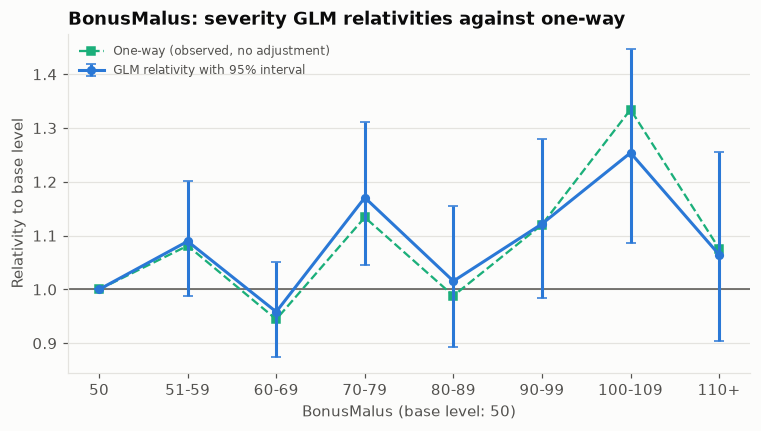

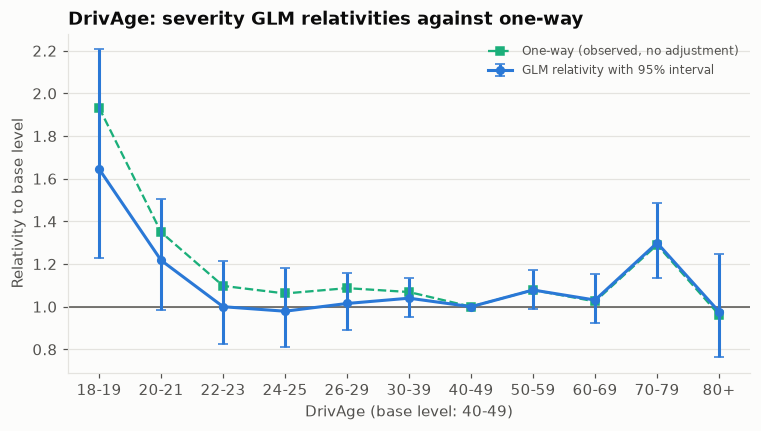

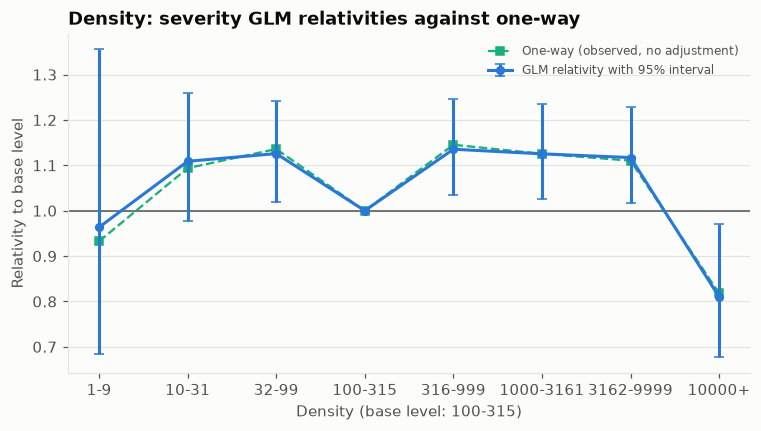

In [9]:
for factor in SEV_FACTORS:
    ow = one_way_table(sev_train_b, factor).with_columns(pl.col("severity").alias("frequency"))
    fig = plot_relativities(rel, ow, factor, band_labels(BANDS[factor]))
    fig.axes[0].set_title(f"{factor}: severity GLM relativities against one-way")
    save(fig, f"sev_glm_relativities_{factor.lower()}")
    plt.show()

The severity relativities are much flatter than the frequency ones and their intervals are wider. The clearest effects are higher costs for the youngest drivers (18-19, with a wide interval), for drivers aged 70-79, and for BonusMalus 100-109. Several patterns are not monotone, for example Density rising then falling in the densest band. A pricing team would usually smooth or group such bands before putting them in a rating table; they are left as fitted here.

## 5. Gamma GBM

The GBM uses the same raw features as the frequency GBM, a Gamma objective, and claim count as the sample weight. Because the signal is weak, a lower learning rate (0.01) and small trees are tried, with the number of trees set by early stopping.

In [10]:
X_train_gbm = gbm_matrix(sev_train)
grid = [{"learning_rate": 0.01, "num_leaves": nl, "min_data_in_leaf": md} for nl in (3, 7, 15) for md in (100, 300)]
gbm_rows = []
for params in grid:
    rounds, score = cv_gamma_gbm(X_train_gbm, y_train, w_train, params)
    gbm_rows.append({**params, "trees": rounds, "cv_lgb_gamma_deviance": score})
gbm_cv = pl.DataFrame(gbm_rows).sort("cv_lgb_gamma_deviance")
gbm_cv

learning_rate,num_leaves,min_data_in_leaf,trees,cv_lgb_gamma_deviance
f64,i64,i64,i64,f64
0.0100,15,100,75,4980.4402
0.0100,3,300,281,4980.9703
0.0100,7,300,84,4981.0455
0.0100,7,100,86,4981.4538
0.0100,15,300,74,4982.4864
0.0100,3,100,193,4983.4045


In [11]:
best = gbm_cv.row(0, named=True)
gbm_params = {k: best[k] for k in ("learning_rate", "num_leaves", "min_data_in_leaf")}
gbm_rounds = best["trees"]

oof["GBM"] = np.zeros_like(y_train)
for fit_idx, val_idx in folds:
    m = SeverityGBM(gbm_params, gbm_rounds).fit(X_train_gbm.iloc[fit_idx], y_train[fit_idx], w_train[fit_idx])
    oof["GBM"][val_idx] = m.predict(X_train_gbm.iloc[val_idx])

compare = {"no factors": "no factors", "GLM": "BonusMalus, DrivAge, Density", "GBM": "GBM"}
pl.DataFrame([
    {"model": label, "cv_gamma_deviance": gamma_deviance(y_train, oof[key], w_train),
     "cv_gini": gini(y_train * w_train, oof[key], w_train)}
    for label, key in compare.items()
])

model,cv_gamma_deviance,cv_gini
str,f64,f64
"""no factors""",1.1880,-0.0091
"""GLM""",1.1818,0.0474
"""GBM""",1.1833,0.0365


The GBM stops early, after fewer than 100 trees at a low learning rate, and does not beat the three-factor GLM in cross-validation. With this much noise in claim cost, the flexibility that helped the GBM on frequency finds little extra to use here.

## 6. Test set

Both final models are fitted on all training claims and scored once on the test claims.

In [12]:
gbm = SeverityGBM(gbm_params, gbm_rounds).fit(X_train_gbm, y_train, w_train)
sev_test_b = add_glm_bands(sev_test)
pred_test = {
    "GLM": predict(glm, glm_design_matrix(sev_test_b, sev_levels, base)),
    "GBM": gbm.predict(gbm_matrix(sev_test)),
}
cost_test = sev_test["ClaimAmount"].to_numpy()
rows = [{"model": "no factors", "gamma_deviance": gamma_deviance(y_test, np.full_like(y_test, train_mean), w_test),
         "gini": 0.0, "balance": balance(cost_test, np.full_like(y_test, train_mean), w_test)}]
for m, p in pred_test.items():
    rows.append({"model": m, "gamma_deviance": gamma_deviance(y_test, p, w_test),
                 "gini": gini(cost_test, p, w_test), "balance": balance(cost_test, p, w_test)})
pl.DataFrame(rows)

model,gamma_deviance,gini,balance
str,f64,f64,f64
"""no factors""",1.2381,0.0000,0.9702
"""GLM""",1.2449,0.0141,0.9723
"""GBM""",1.2346,0.0366,0.9545


On the test set the ranking differs from cross-validation: the GLM does slightly worse than the no-factor model, and the GBM slightly better. Before reading anything into that, check how large these differences are compared with sampling noise. The bootstrap below resamples the test claims 1,000 times and recomputes each model's deviance minus the no-factor model's deviance (negative means better than no factors).

In [13]:
rng = np.random.default_rng(RANDOM_SEED)
null_pred = np.full_like(y_test, train_mean)
diffs = {m: [] for m in pred_test}
for _ in range(1000):
    i = rng.integers(0, len(y_test), len(y_test))
    null_dev = gamma_deviance(y_test[i], null_pred[i], w_test[i])
    for m, p in pred_test.items():
        diffs[m].append(gamma_deviance(y_test[i], p[i], w_test[i]) - null_dev)
pl.DataFrame([
    {"model": m, "deviance vs no factors": gamma_deviance(y_test, pred_test[m], w_test) - gamma_deviance(y_test, null_pred, w_test),
     "95% interval low": np.quantile(d, 0.025), "95% interval high": np.quantile(d, 0.975)}
    for m, d in diffs.items()
])

model,deviance vs no factors,95% interval low,95% interval high
str,f64,f64,f64
"""GLM""",0.0069,-0.0132,0.0278
"""GBM""",-0.0034,-0.0130,0.0062


Read with the cross-validation results, the picture is consistent: **neither severity model is reliably better than charging the same average claim cost to everyone**. Cross-validation (on four times as many claims) favoured the GLM by a small margin, the test set favours the GBM by a small margin, and each difference is of the size that sampling noise produces with a few thousand claims.

This is a genuine finding rather than a failure of either model. Once large losses are capped, the rating factors in this dataset say very little about how much a claim will cost. Nearly all of the risk differentiation between policies comes from frequency. The severity models are still carried into the pure premium, since a severity model with little signal does little harm when multiplied by frequency, but the conclusion is worth stating plainly in the README.

Both models also predict about 3 to 5% less claim cost on the test set than was observed. As with frequency, the test claims are on average a little more expensive than the training claims (see the no-factor model's balance of 0.97), so this is mostly the split rather than the models.

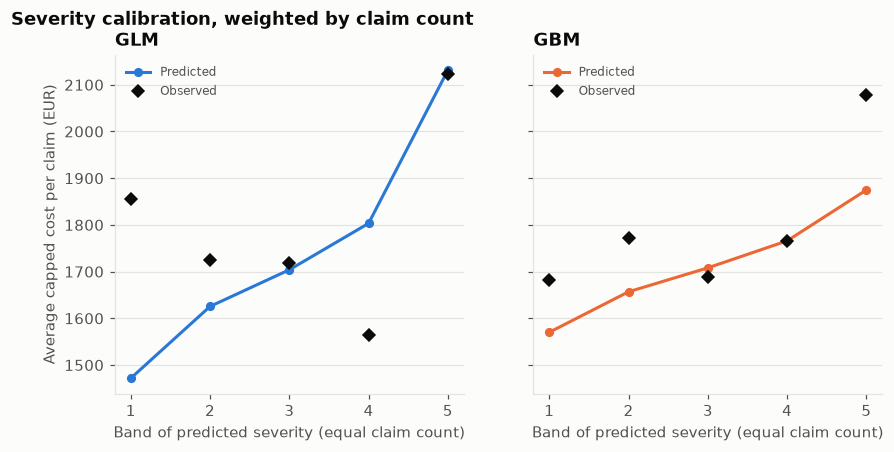

In [14]:
calib = {m: calibration_table(cost_test, p, w_test, n_bins=5) for m, p in pred_test.items()}
fig = plot_calibration(
    calib, ylabel="Average capped cost per claim (EUR)",
    xlabel="Band of predicted severity (equal claim count)", title="Severity calibration, weighted by claim count",
)
save(fig, "sev_calibration_test")
plt.show()

Five bands are used rather than ten because the test set has only about 5,000 claims, and each band's observed average is noisy. Neither model sorts claims reliably by cost: the GLM's lowest-predicted band has one of the highest observed averages, and the GBM's predictions span a narrow range (about EUR 1,550 to 1,900) while the observed averages jump around it. This is what a weak signal looks like on a calibration chart.

## 7. Save predictions for the pure premium notebook

Pure premium needs a predicted severity for **every** test policy, not only those that claimed, so both models are applied to the whole test set. The large-loss loading is saved alongside.

In [15]:
test_capped_b = add_glm_bands(test_capped)
test_capped.select("IDpol", "SevNb", "ClaimAmount", "ClaimAmountExcess").with_columns(
    pl.Series("sev_glm", predict(glm, glm_design_matrix(test_capped_b, sev_levels, base))),
    pl.Series("sev_gbm", gbm.predict(gbm_matrix(test_capped))),
).write_parquet(PROCESSED / "severity_test_predictions.parquet")

glm.remove_data()
with open(PROCESSED / "severity_glm.pkl", "wb") as fh:
    pickle.dump({"results": glm, "levels": sev_levels, "base": base, "large_loss_loading": loading}, fh)
gbm.booster.save_model(PROCESSED / "severity_gbm.txt")